<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/03_Redes_neuronales_artificiales/translearn.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [1]:
#####################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)          #
# E-mail: wgomez@cinvestav.mx                       #
# Curso:  Análisis de datos                         #
# Tópico: Transferencia de aprendizaje usando VGG16 #
#####################################################

In [2]:
!nvidia-smi

Tue Mar 24 02:46:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Carga bibliotecas necesarias

In [42]:
# Libraries
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Machine learning
import os                                                             # Interaction with the operating system
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gdown                                                          # Downloads a public file/folder from Google Drive
import glob
from sklearn.model_selection import train_test_split
import pandas as pd                                                   # Added for flow_from_dataframe
from sklearn.preprocessing import LabelEncoder

Descarga la base de datos de PERROS y GATOS

In [4]:
# Download cats_dogs.zip dataset
!gdown --id 1w0frx8GPvFEFCTLcR0Zjl-qpb54PhLVb --output cats_dogs.zip

# Unzip cats_dogs.zip file
!unzip -q '/content/cats_dogs.zip' -d '/content/'

# Remove cats_dogs.zip file
!rm '/content/cats_dogs.zip'

# Paths
dataset = 'cats_dogs'
path = '/content/' + dataset + '/'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1w0frx8GPvFEFCTLcR0Zjl-qpb54PhLVb
From (redirected): https://drive.google.com/uc?id=1w0frx8GPvFEFCTLcR0Zjl-qpb54PhLVb&confirm=t&uuid=ca3ec7d9-5128-4b40-9677-20c35cf67a18
To: /content/cats_dogs.zip
100% 228M/228M [00:02<00:00, 106MB/s] 


Divide en entrenamiento, validación y prueba

In [54]:
image_files = glob.glob(path + "/*.jpg") # Get all image paths
labels = [os.path.basename(f).split('.')[0] for f in image_files] # Extract labels
# First split: 85% train+val, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_files, labels, test_size=0.15, random_state=42, stratify=labels
)
# Second split: Split train+val into 70% train and 15% validation (approx)
# 0.17647 * 0.85 = 0.15
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.17647, random_state=42, stratify=y_train_val
)

# Create DataFrames for train, validation, and test sets
train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
val_df = pd.DataFrame({'filename': X_val, 'class': y_val})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

Training images



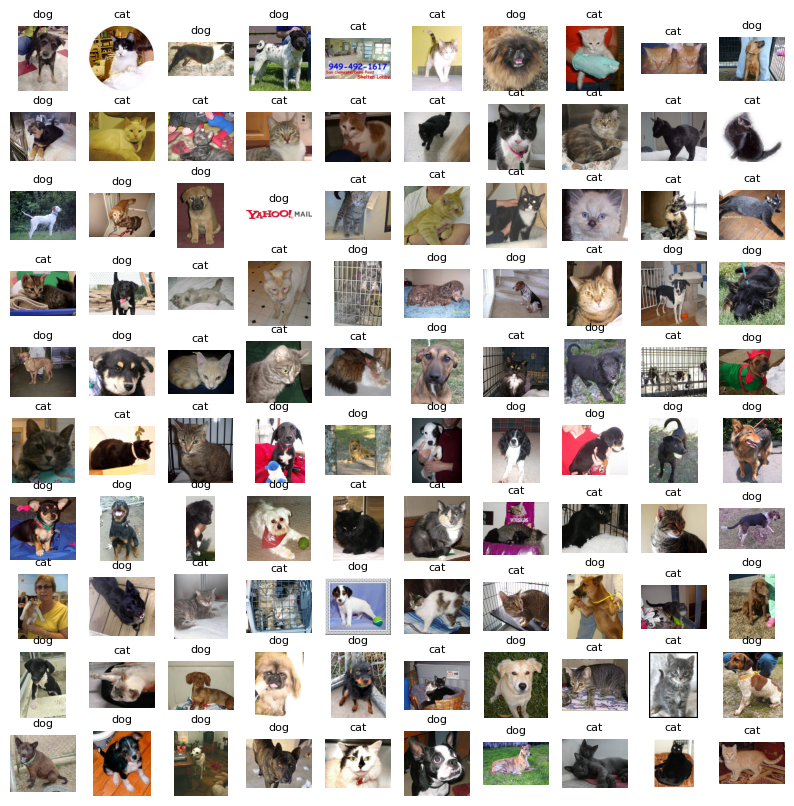

In [55]:
# Data visualization
ncols = 10
nrows = 10
# Shuffle data
ind = np.random.permutation(len(y_train))
pictures = np.array(X_train)[ind]
clas = np.array(y_train)[ind]
# Create figure
fig, axs = plt.subplots(figsize=(10, 10))
plt.axis('off')
print('Training images\n')
for i in range(ncols * nrows):
  axs = fig.add_subplot(nrows, ncols, i + 1)
  img = plt.imread(pictures[i])
  axs.imshow(img)
  axs.axis('off')
  label = str(clas[i])
  plt.title(label, fontsize=8)
plt.show()

In [56]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0,
                                     zoom_range=0.3,
                                     rotation_range=90,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     brightness_range=[0.5, 1.5],
                                     fill_mode='constant')
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)

batch_size = 128
class_mode = 'binary'
outputs_n = 1
activation = 'sigmoid'
loss = 'binary_crossentropy'

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size = (224, 224),
    batch_size = batch_size,
    color_mode = 'rgb',
    class_mode = class_mode,
    seed=42,
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size = (224, 224),
    batch_size = batch_size,
    color_mode = 'rgb',
    class_mode = class_mode,
    seed=42,
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size = (224, 224),
    batch_size = batch_size,
    color_mode = 'rgb',
    class_mode = class_mode,
    seed=42,
    shuffle=False
)

Found 7018 validated image filenames belonging to 2 classes.
Found 1505 validated image filenames belonging to 2 classes.
Found 1505 validated image filenames belonging to 2 classes.


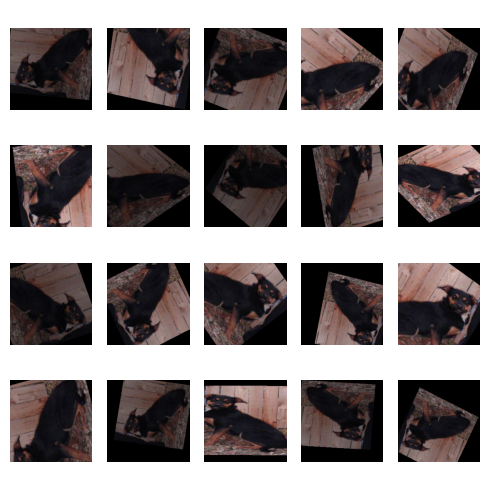

In [58]:
# Visualize data augmentation
def plottingImages(images):
    plt.subplots(figsize = (5, 5))
    cols = 5
    rows = len(images) // cols
    plt.axis('off')

    for c, img in enumerate(images):
        plt.subplot(rows, cols, c + 1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

augmented_images = [train_generator[0][0][0] for i in range(20)]
plottingImages(augmented_images)

In [59]:
# Transfer learning
base_model = tf.keras.applications.VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3))

base_model.trainable = False
#base_model.summary() # Show architecture

In [60]:
# Freeze trainable layers
freeze_all = False

if freeze_all:
  base_model.trainable = False # Freeze all trainable layers
else:
  base_model.trainable = True # Unfreeze all trainable layers
  fine_tune_at = 15 # Freeze until block5
  for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False # Freeze some trainable layers

# Layers of the base model
for i, layer in enumerate(base_model.layers[:]):
  print(f'{i}: {layer.name}, {layer.trainable}')

0: input_layer_1, False
1: block1_conv1, False
2: block1_conv2, False
3: block1_pool, False
4: block2_conv1, False
5: block2_conv2, False
6: block2_pool, False
7: block3_conv1, False
8: block3_conv2, False
9: block3_conv3, False
10: block3_pool, False
11: block4_conv1, False
12: block4_conv2, False
13: block4_conv3, False
14: block4_pool, False
15: block5_conv1, True
16: block5_conv2, True
17: block5_conv3, True
18: block5_pool, True


In [61]:
# Assembling model with new output
x = base_model.output # VGG
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Flatten with GAP
output = tf.keras.layers.Dense(1, activation = 'sigmoid')(x) # Output
model = tf.keras.Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 7,079,937 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [62]:
# Compile model
adam = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True
) # Early stopping

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
) # Learning rate schedule

# Train model
epochs = 50
history = model.fit(train_generator,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(val_generator),
                    verbose=1,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7159 - loss: 0.5464 - val_accuracy: 0.8804 - val_loss: 0.3149 - learning_rate: 1.0000e-04
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8266 - loss: 0.3894 - val_accuracy: 0.9229 - val_loss: 0.2157 - learning_rate: 1.0000e-04
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8685 - loss: 0.3152 - val_accuracy: 0.9316 - val_loss: 0.1709 - learning_rate: 1.0000e-04
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8662 - loss: 0.3036 - val_accuracy: 0.9289 - val_loss: 0.1785 - learning_rate: 1.0000e-04
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8807 - loss: 0.2786 - val_accuracy: 0.9296 - val_loss: 0.1942 - learning_rate: 1.0000e-04
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8913 - loss: 0.2594 - val_accuracy: 0.9429 - val_loss: 0.1491 - learning_rate: 1.0000e-04
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9010 - loss:

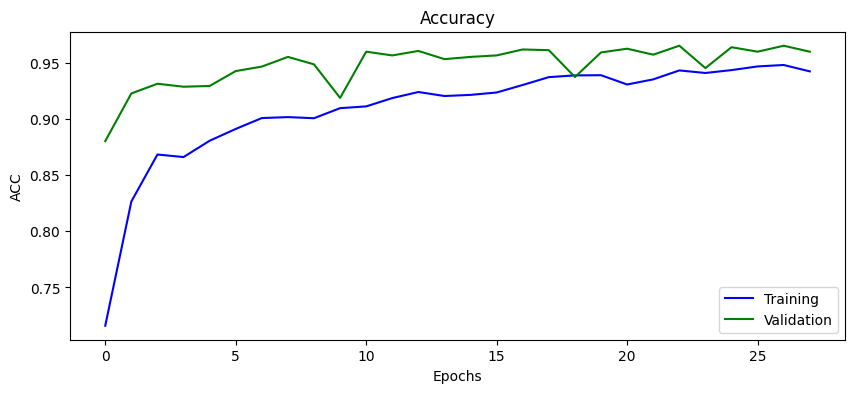

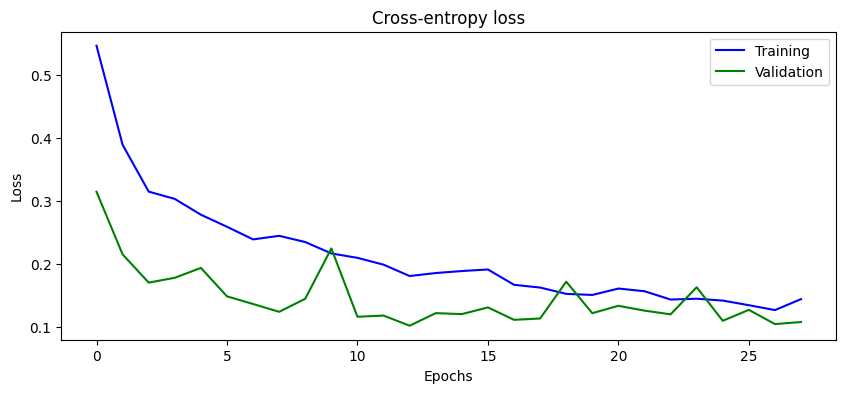

In [63]:
# Training and validation graphs
training_acc = history.history['accuracy']
validation_acc = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epocas = np.arange(len(training_loss))

plt.figure(figsize=(10, 4))
plt.plot(epocas, training_acc, color='blue', label='Training')
plt.plot(epocas, validation_acc, color = 'green', label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('ACC')
plt.legend()
plt.show()
print()

plt.figure(figsize = (10, 4))
plt.plot(epocas, training_loss, color='blue', label='Training')
plt.plot(epocas, validation_loss, color = 'green', label='Validation')
plt.title('Cross-entropy loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Accuracy: 0.957


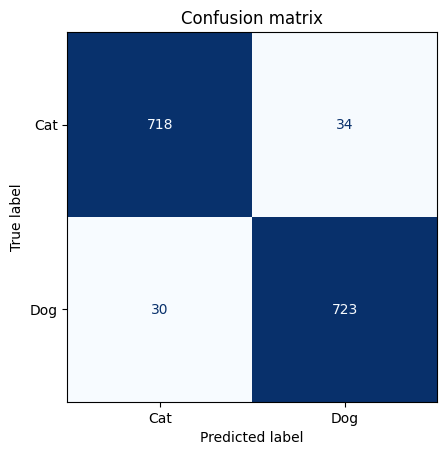

In [64]:
# Get true labels and predictions from test set
test_generator.reset()
Y_true  = np.array(test_generator.labels)
Y_true = Y_true.reshape(-1, 1)
Y_probs = model.predict(test_generator, verbose = 0)
Y_pred  = np.round(Y_probs)
ACC = np.mean(Y_pred == Y_true)
print(f"Accuracy: {ACC:.3f}")

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()

{0: 'cat', 1: 'dog'}
Testing images



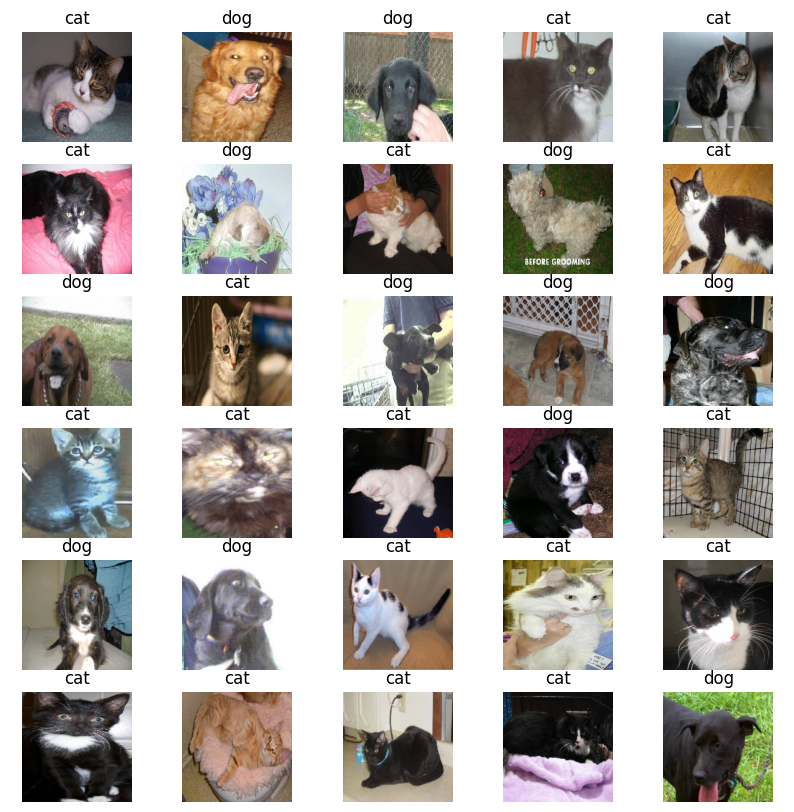

In [68]:
# Model prediction
batch = next(test_generator)
images = batch[0]
targets = batch[1]

results = model.predict(images, verbose = 0)
results = np.round(results)

dict_classes = test_generator.class_indices
dict_classes = {v:k for k, v in dict_classes.items()}
print(dict_classes)

# Data visualization
ncols = 5
nrows = 6
# Create figure
fig, axs = plt.subplots(figsize=(10, 10))
plt.axis('off')
print('Testing images\n')
for i in range(ncols * nrows):
  axs = fig.add_subplot(nrows, ncols, i + 1)
  axs.imshow(images[i], cmap='gray')
  axs.axis('off')
  label = str(dict_classes[targets[i]])
  if targets[i] != results[i]:
    plt.title(label, color='red')
  else:
    plt.title(label)
plt.show()